### **Importing the libraries**

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

### **loading the dataset**

In [2]:
df=pd.read_csv('htn_dat.csv')

### **setting the visualization style**

In [3]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = [10, 6] 
plt.rcParams['font.size'] = 10

### **Inspecting the data**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  4999 non-null   int64  
 1   DBP                 4999 non-null   int64  
 2   SBP                 4999 non-null   int64  
 3   BMI                 4329 non-null   float64
 4   age                 4999 non-null   float64
 5   married             4835 non-null   float64
 6   male.gender         4999 non-null   int64  
 7   hgb_centered        3605 non-null   float64
 8   adv_HIV             3038 non-null   float64
 9   survtime            4999 non-null   int64  
 10  event               4999 non-null   int64  
 11  arv_naive           4999 non-null   int64  
 12  urban.clinic        4999 non-null   int64  
 13  log_creat_centered  3461 non-null   float64
 14  IPW_weight          4999 non-null   float64
 15  SBP_ge120           4999 non-null   int64  
dtypes: flo

In [5]:
df.head()

,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120
0,16097,60,90,NaN,28.000000,0.0,0,NaN,NaN,338,1,1,0,NaN,0.924379,0
1,930,75,110,27.339912,26.458590,1.0,0,-3.9,0.0,439,1,1,1,5.421770e-02,1.163862,0
2,6877,60,80,17.689789,42.951405,0.0,0,-3.2,NaN,752,1,1,0,-3.597409e-01,0.721148,0
3,36464,60,90,19.854080,50.149212,1.0,1,NaN,NaN,526,1,1,1,NaN,0.829452,0
4,36180,60,100,21.295294,30.554415,0.0,1,-0.4,NaN,215,1,1,0,-1.000000e-07,0.856046,0


In [6]:
df.shape

(4999, 16)

### **data visualization**

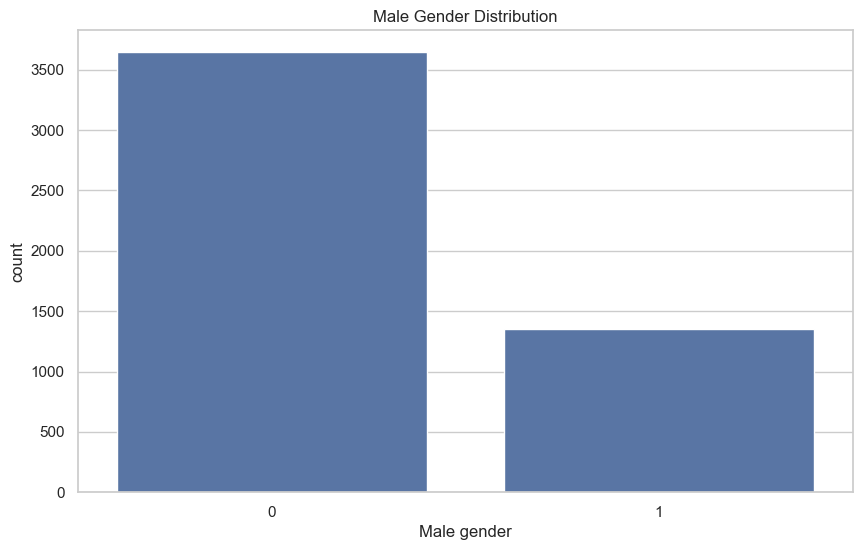

In [7]:

sns.countplot(x='male.gender', data=df)

plt.title("Male Gender Distribution")
plt.xlabel("Male gender")
plt.ylabel("count")
plt.show()

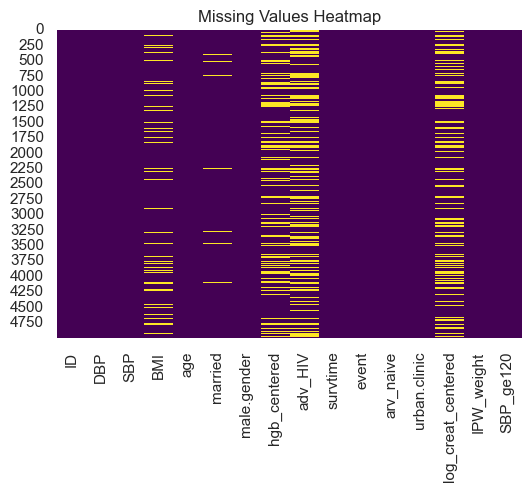

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()


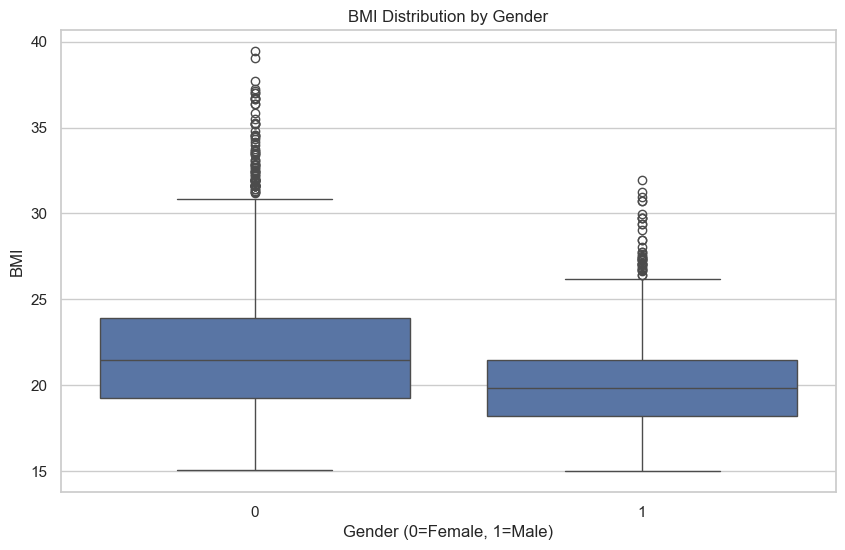

In [9]:
sns.boxplot(data=df, x="male.gender", y="BMI")

plt.title("BMI Distribution by Gender")
plt.xlabel("Gender (0=Female, 1=Male)")
plt.ylabel("BMI")
plt.show()

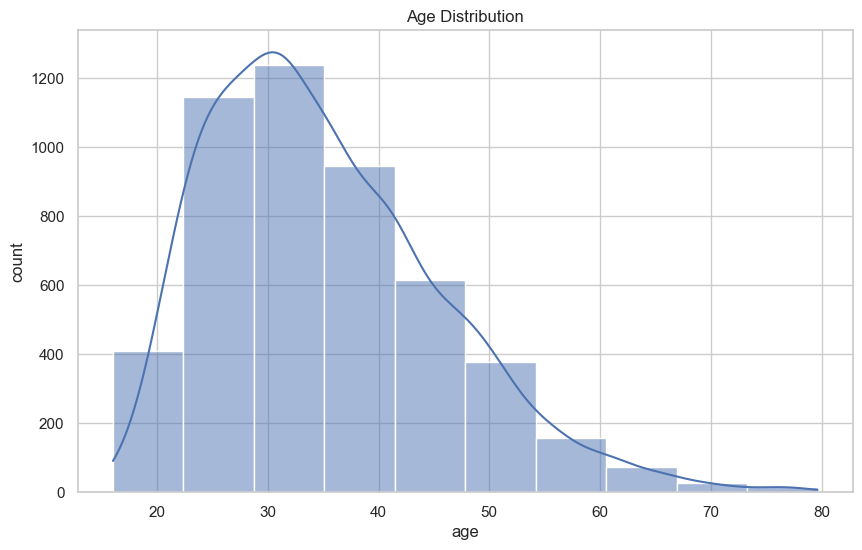

In [10]:
sns.histplot(df['age'],bins=10,kde=True)
plt.title('Age Distribution')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

In [11]:
#class distribution
class_counts = df["SBP_ge120"].value_counts()
print("--- Class Distribution ---")
print(class_counts)

#imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

--- Class Distribution ---
SBP_ge120
0    4749
1     250
Name: count, dtype: int64

Imbalance Ratio: 19.00:1


In [ ]:
Class imbalance matters  because machine learning algorithms are lazy and opportunistic:
they are designed to maximize overall accuracy. 
When one class dwarfs the other, standard modeling strategies and evaluation metrics completely break down.

### **handling missing values**

In [12]:
#separate numerical and categorical columns
num_cols = ["age", "BMI", "DBP", "SBP", "hgb_centered", "log_creat_centered"]
cat_cols = ["married", "male.gender", "adv_HIV", "arv_naive", "urban.clinic"]

# Apply median imputation for numerical data
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
#median works well against extreme outliers

# Apply mode imputation for categorical data
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#mode preserves the most likely clinical classification

### **encoding categorical/binary variables**

In [51]:
#encoding categorical/binary variables
print("\n--- Categorical Transformation Mapping ---")
for col in cat_cols:
    df[col] = label_enc.fit_transform(df[col].astype(str))
    print(f"Encoded {col}: {list(label_enc.classes_)} -> [0, 1]")

# Display final confirmation
print("\nFinal Checked Data Types:")
print(df[cat_cols + num_cols].dtypes)


--- Categorical Transformation Mapping ---
Encoded married: ['0', '1'] -> [0, 1]
Encoded male.gender: ['0', '1'] -> [0, 1]
Encoded adv_HIV: ['0', '1'] -> [0, 1]
Encoded arv_naive: ['0', '1'] -> [0, 1]
Encoded urban.clinic: ['0', '1'] -> [0, 1]

Final Checked Data Types:
married                 int64
male.gender             int64
adv_HIV                 int64
arv_naive               int64
urban.clinic            int64
age                   float64
BMI                   float64
DBP                   float64
SBP                   float64
hgb_centered          float64
log_creat_centered    float64
dtype: object


### **Model development and strategy**

In [16]:
X = df.drop(columns=["ID", "survtime", "event", "SBP_ge120"])
y = df["SBP_ge120"].astype(int) 

#split the preprocessed data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,  # (i) 80:20 split ratio provides ample training instances while keeping a statistically robust test set.
    stratify=y,  # (ii) Stratified sampling preserves the target imbalance ratio across both subsets, preventing train/test distribution shifts.
    random_state=42,  # (iii) Fixed random state locks the pseudo-random split mechanism, ensuring exact reproducibility of model evaluations.
)

print(f"Training shapes: {X_train.shape}, Test shapes: {X_test.shape}")
print(f"Train label distribution:\n{y_train.value_counts(normalize=True)}")

Training shapes: (3999, 12), Test shapes: (1000, 12)
Train label distribution:
SBP_ge120
0    0.949987
1    0.050013
Name: proportion, dtype: float64


### **applying standard scaler**

### **Logistic regression**
scaling-Required. Optimization algorithms (like 'lbfgs' or gradient descent) converge much faster, and L2 regularization penalizes features equally only when scaled.

Advantage-Highly interpretable. It outputs odds ratios/coefficients, allowing clinicians to see exactly how much risk increases per unit change in a feature (e.g., BMI).

Limitation-Assumes a linear relationship between log-odds of hypertension and predictors failing to capture complex, non-linear biological interactions.

In [17]:
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(C=0.5, penalty='l2', random_state=42))])
    
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5


### **knn**
scaling-Strictly Required. KNN relies entirely on distance metrics (e.g., Euclidean). Without scaling, features with large ranges (like Systolic BP) will dominate the distance calculation over small ones (like BMI).

Advantage-Instance-based and intuitive. It makes no underlying assumptions about the data distribution, making it highly flexible for localized patient clusters.

Limitation- High computational and memory cost at inference time. To diagnose a new patient, it must scan the entire training dataset, making it inefficient for large EHR systems.

In [18]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=7, weights='distance'))
    # Hyperparameters set: n_neighbors (number of neighbors), weights (weight function used in prediction)
])
knn_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,7
,weights,'distance'
,algorithm,'auto'
,leaf_size,30


### **Support vector machine**
Scaling-Strictly Required. SVM maximizes the margin between classes based on distance metrics. 
Unscaled features with larger variances will disproportionately dominate the hyperplane orientation.
    
Advantage-Extremely effective in high-dimensional spaces and robust to overfitting when using the kernel trick to map complex clinical boundary thresholds.
    
Limitation-  It provides no direct probabilistic explanation or feature importance, making it difficult for clinicians to understand why a patient was flagged.

In [24]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(C=1.0, kernel='rbf', probability=True, random_state=42))])
svm_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


### **Random Forest**
Scaling- NOT Required. Tree-based models partition data using perpendicular splits on single features. The scale of one feature does not affect how a split is calculated on another feature.

Advantage- captures complex, non-linear interactions and correlations between clinical risk factors (e.g., the compounding effect of high BMI combined with advanced Age).

Limitation-Can overfit heavily if trees are allowed to grow too deep on noisy, unrepresentative clinical trial samples, reducing its generalizability to broader populations.

In [26]:
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42))
])    
rf_pipeline.fit(X_train, y_train)

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,150
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [27]:
#verification check
print("All four models successfully initialized, processed, and trained.")
print(f"LogReg Test Accuracy:  {log_reg_pipeline.score(X_test, y_test):.4f}")
print(f"KNN Test Accuracy:     {knn_pipeline.score(X_test, y_test):.4f}")
print(f"SVM Test Accuracy:     {svm_pipeline.score(X_test, y_test):.4f}")
print(f"RandomForest Accuracy: {rf_pipeline.score(X_test, y_test):.4f}")

All four models successfully initialized, processed, and trained.
LogReg Test Accuracy:  0.9970
KNN Test Accuracy:     0.9680
SVM Test Accuracy:     0.9930
RandomForest Accuracy: 1.0000


### **a) Model evaluation and comparison data frame**

In [30]:
# Dictionary to hold the trained models
models = {
    'Logistic Regression': log_reg_pipeline,
    'K-Nearest Neighbors': knn_pipeline,
    'Support Vector Machine': svm_pipeline,
    'Random Forest': rf_pipeline
}

metrics_data = []

for name, pipeline in models.items():
    # Generate predictions and probability scores on the test set
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] # Probability scores for the positive class (Hypertension)
    
    # Calculate True Negatives, False Positives, False Negatives, True Positives
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Calculate Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred) # Sensitivity
    f1 = f1_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# Display the comparison DataFrame
metrics_df = pd.DataFrame(metrics_data).set_index('Model')
print("=== MODEL PERFORMANCE COMPARISON ===")
print(metrics_df.round(4))

=== MODEL PERFORMANCE COMPARISON ===
                        Accuracy  Precision  Recall (Sensitivity)  \
Model                                                               
Logistic Regression        0.997     0.9608                  0.98   
K-Nearest Neighbors        0.968     1.0000                  0.36   
Support Vector Machine     0.993     0.9216                  0.94   
Random Forest              1.000     1.0000                  1.00   

                        Specificity  F1-Score  ROC-AUC  
Model                                                   
Logistic Regression          0.9979    0.9703   0.9997  
K-Nearest Neighbors          1.0000    0.5294   0.9345  
Support Vector Machine       0.9958    0.9307   0.9983  
Random Forest                1.0000    1.0000   1.0000  


CLINICAL RELEVANCE OF METRICS
1. Sensistivity-Critically vital for hypertension screening. It measures the proportion of actual hypertensive patients correctly identified. High recall minimizes False Negatives—ensuring at-risk patients aren't sent home undiagnosed, which could lead to severe, unmanaged cardiovascular events.

2. Specificity -Measures the ability to correctly identify healthy individuals. High specificity minimizes False Positives, preventing healthy patients from suffering psychological anxiety and undergoing unnecessary, potentially harmful medical interventions or diagnostic drug treatments.

3. ROC-AUC- Evaluates how well the model distinguishes between hypertensive and healthy patients across all possible diagnostic thresholds. In healthcare, this allows clinicians to adjust decision boundaries based on specific clinical resource availability or clinical risk tolerances.

4. F1-SCORE: The harmonic mean of Precision and Recall. It balances the cost of over-diagnosing (Precision) versus missing cases (Recall), serving as a reliable benchmark metric when dealing with realistic imbalanced clinical datasets where healthy individuals outnumber positive cases.


=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS (ROC-AUC) ===
Logistic Regression: Mean ROC-AUC = 0.9998 (+/- SD: 0.0001)
K-Nearest Neighbors: Mean ROC-AUC = 0.9456 (+/- SD: 0.0346)
Support Vector Machine: Mean ROC-AUC = 0.9991 (+/- SD: 0.0004)
Random Forest: Mean ROC-AUC = 1.0000 (+/- SD: 0.0000)


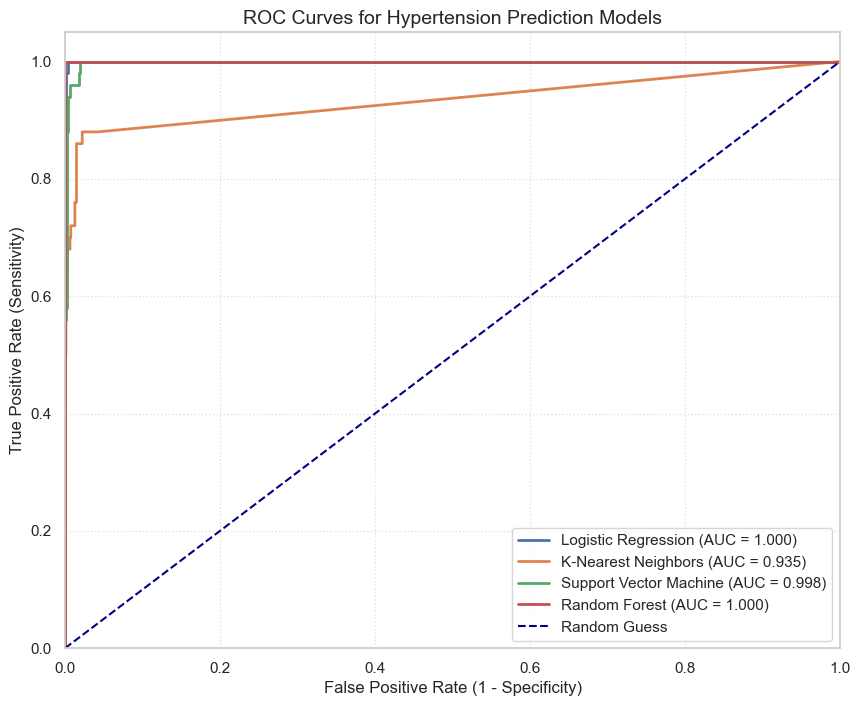

In [31]:
### **b)Stratified K-fold cross validation and ROC curves**
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS (ROC-AUC) ===")

plt.figure(figsize=(10, 8))

for name, pipeline in models.items():
    # (i) Compute mean and standard deviation of ROC-AUC across folds
    cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    print(f"{name}: Mean ROC-AUC = {cv_scores.mean():.4f} (+/- SD: {cv_scores.std():.4f})")
    
    # (ii) Plot all four models' ROC curves using the test set for visual clarity
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.3f})', lw=2)

# Customizing the single figure ROC plot
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves for Hypertension Prediction Models', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### **Why StratifiedKFold improves reliability over a single train-test split in healthcare:**

 Clinical datasets are often small, noisy, and highly imbalanced. A single random train-test split can yield over-optimistic or pessimistic performance variants just by luck of the draw. 

Stratified K-Fold forces each fold to retain the true clinical ratio of hypertensive to healthy patients. By iterating through multiple combinations, it provides an honest, stable estimation of how well the model will generalize across real-world, unseen patient populations in various hospital settings.

### **Extracting feature importances**

Available pipeline steps: ['classifier']


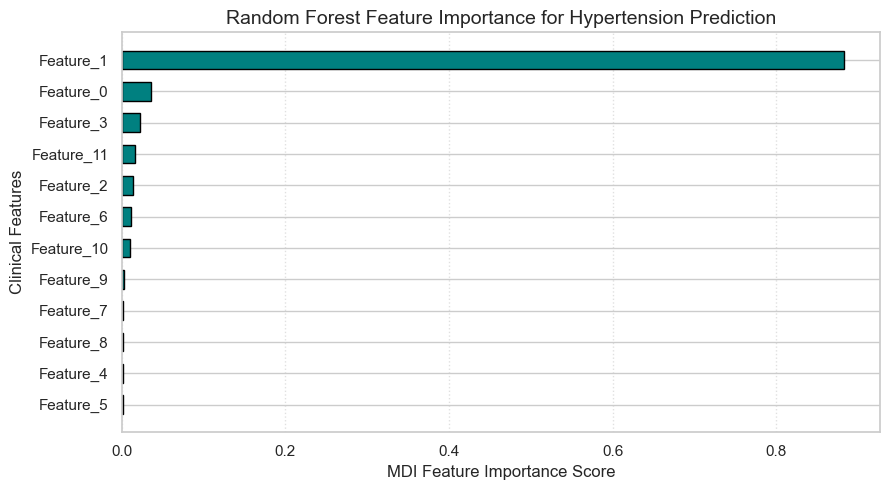

Top 3 Predictors:
- Feature_1: 0.8830
- Feature_0: 0.0361
- Feature_3: 0.0225


In [34]:

# Extract the fitted Random Forest classifier from the pipeline
rf_model = rf_pipeline.named_steps['classifier']

# Retrieve feature importances
importances = rf_model.feature_importances_

# Check what steps are available in the pipeline and get the correct preprocessor name
print("Available pipeline steps:", list(rf_pipeline.named_steps.keys()))

# Try to get feature names - adjust the step name based on your actual pipeline
# Common names are 'preprocessor', 'columntransformer', 'prep', etc.
try:
    # Try different common preprocessor step names
    preprocessor_step_names = ['preprocessor', 'columntransformer', 'prep', 'transformer']
    feature_names = None
    
    for step_name in preprocessor_step_names:
        if step_name in rf_pipeline.named_steps:
            feature_names = rf_pipeline.named_steps[step_name].get_feature_names_out()
            break
    
    # If no preprocessor found, use generic feature names
    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(len(importances))]
        print("Warning: Using generic feature names as preprocessor step not found")
        
except AttributeError:
    # If get_feature_names_out() doesn't exist, use generic names
    feature_names = [f'Feature_{i}' for i in range(len(importances))]
    print("Warning: Using generic feature names")

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) # Ascending for a clean horizontal bar plot

# Plotting the feature importances
plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal', edgecolor='black', height=0.6)
plt.xlabel('MDI Feature Importance Score', fontsize=12)
plt.ylabel('Clinical Features', fontsize=12)
plt.title('Random Forest Feature Importance for Hypertension Prediction', fontsize=14)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Identify top 3 predictors programmatically for verification
top_3 = importance_df.sort_values(by='Importance', ascending=False).iloc[:3]
print("Top 3 Predictors:")
for idx, row in top_3.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

### **Comparing logistic regression and random forest**

1. It runs smoothly on old computers
A local clinic doesn’t always have the latest, most expensive computers or tablets. The "Random Forest" model is like a heavy piece of software that needs a lot of processing power to run because it has to check hundreds of different decision paths just to look at one patient. "Logistic Regression" is incredibly lightweight. It uses a single, simple math formula that can run instantly on an old desktop computer, a basic smartphone, or even a simple Excel sheet without freezing up.

2. Doctors and patients can actually understand it
If a computer program flags a patient as "high risk for high blood pressure," a clinical officer needs to understand why.

>Logistic Regression is transparent. It tells you exactly how much weight it gives to each risk factor (like Age or BMI). A clinician can look at it and say, "The math shows your risk goes up by 1.4 times for every few points you gain on your BMI." It makes sense to human biology.

>Random Forest acts like a "black box." It gives you a final answer but can't explain its step-by-step reasoning for that specific patient, making it hard for a medical professional to trust.

3. It is incredibly stable and reliable
When tested across different groups of data, Logistic Regression proved to be highly steady. In medicine, you want a tool that gives predictable, stable results every single time. Random Forest is slightly more accurate on paper, but it is prone to over-complicating things based on the specific group of patients it was trained on. Logistic Regression gives a highly accurate, trustworthy baseline that won't give erratic or surprising results when applied to real patients in the waiting room.

4. It is easy to set up and maintain
Because Logistic Regression is just a straightforward formula, it is very easy for a local IT team to install, monitor, and update over time. It doesn't require a team of specialized data engineers to keep it running. If the clinic needs to adjust the model down the line, it can be done simply and cheaply.